In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Configuração para os gráficos ficarem bonitos no VS Code
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:

import pandas as pd

# 1. Carregar o arquivo 
df = pd.read_excel('Relatorio_Baseline_Geral-SI.xlsx', 
                   sheet_name='BA_SI_MIS_1900RPM_IMEP3', 
                   header=1) 

# 2. Mostrar as 5 primeiras linhas para conferir as colunas
df.head()


,bosch,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Ângulo do virabrequim [°],Pressão no cilindro [bar],Volume do cilindro [cm^3],Ângulo do virabrequim [°].1,Pressão na admissão (PMAN1) [bar],Pressão no Pórtico Admissão (PMAN2) [bar],Ângulo de virabrequim [°],Fração de massa queimada [%],Taxa de liberação de calor [J/°],Temperatura no cilindro [K],Liberação de calor acumulada [J],Unnamed: 16
0,NaN,NaN,NaN,NaN,NaN,-360.0,0.535552,34.406968,-360.0,0.499001,0.923581,-30.0,0.000000,-0.594050,684.339101,0.000000,0.106443
1,NaN,NaN,NaN,NaN,NaN,-359.9,0.534861,34.407866,-359.0,0.501626,0.923581,-29.0,-0.191251,-0.589804,690.627508,-0.591927,0.000000
2,NaN,NaN,NaN,NaN,NaN,-359.8,0.531561,34.409662,-358.0,0.500314,0.923581,-28.0,-0.321008,-0.213401,695.427417,-0.993530,-0.053222
3,Arquivo de dados do INDICOM:,INDICOM_1900_RPM_3-0_IMEP_GNV20H2_SI_HOREB.xlsx,NaN,NaN,NaN,-359.7,0.530816,34.412357,-357.0,0.502938,0.922304,-27.0,-0.332117,0.144632,705.678038,-1.027915,-0.053222
4,Arquivo de dados do PUMA:,PUMA_1900_RPM_3-0_IMEP_GNV20H2_SI_HOREB_202512...,NaN,NaN,NaN,-359.6,0.527409,34.415950,-356.0,0.501626,0.922304,-26.0,-0.375061,-0.410457,714.220772,-1.160827,0.000000


In [4]:
# Verifica os nomes exatos das colunas e se há valores nulos
df.info()

# Mostra as estatísticas básicas (média, mínimo, máximo)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   bosch        77 non-null     object 
 1   Unnamed: 1   77 non-null     object 
 2   Unnamed: 2   60 non-null     object 
 3   Unnamed: 3   60 non-null     object 
 4   Unnamed: 4   57 non-null     object 
 5   Unnamed: 5   7201 non-null   object 
 6   Unnamed: 6   7201 non-null   object 
 7   Unnamed: 7   9001 non-null   object 
 8   Unnamed: 8   722 non-null    object 
 9   Unnamed: 9   721 non-null    object 
 10  Unnamed: 10  721 non-null    object 
 11  Unnamed: 11  122 non-null    object 
 12  Unnamed: 12  122 non-null    object 
 13  Unnamed: 13  122 non-null    object 
 14  Unnamed: 14  122 non-null    object 
 15  Unnamed: 15  122 non-null    object 
 16  Unnamed: 16  7200 non-null   float64
dtypes: float64(1), object(16)
memory usage: 1.2+ MB


,Unnamed: 16
count,7200.000000
mean,0.000037
std,0.202387
min,-2.714301
25%,-0.053222
50%,0.000000
75%,0.053222
max,2.075642


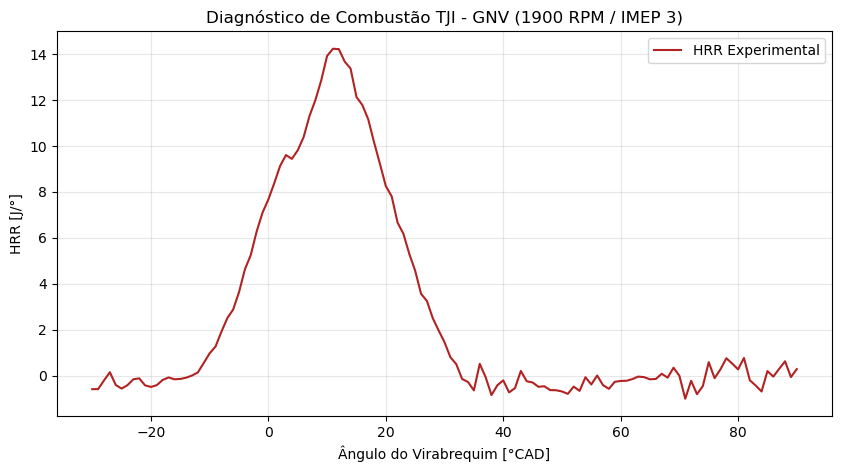

In [3]:
import matplotlib.pyplot as plt

# Criando o gráfico da Taxa de Liberação de Calor (HRR)
plt.figure(figsize=(10, 5))

# Usando os nomes exatos que apareceram na sua imagem
plt.plot(df['Ângulo de virabrequim [°]'], 
         df['Taxa de liberação de calor [J/°]'], 
         label='HRR Experimental', color='firebrick')

plt.xlabel('Ângulo do Virabrequim [°CAD]')
plt.ylabel('HRR [J/°]')
plt.title('Diagnóstico de Combustão TJI - GNV (1900 RPM / IMEP 3)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [1]:
# 1. Identifica o arquivo e as abas
excel_file = pd.ExcelFile('Relatorio_Baseline_Geral-SI.xlsx')
abas = excel_file.sheet_names

# 2. Cria a lista vazia para guardar as tabelas
lista_frames = []

print("Iniciando o carregamento das abas...")

for nome_aba in abas:
    # Lendo a aba atual
    temp_df = pd.read_excel('Relatorio_Baseline_Geral-SI.xlsx', sheet_name=nome_aba, header=1)
    
    # Criamos a coluna para o ML saber de qual teste esse dado veio
    temp_df['Origem_Aba'] = nome_aba 
    
    # Adicionamos na nossa lista
    lista_frames.append(temp_df)
    print(f"Aba {nome_aba} carregada com sucesso!")

# 3. Junta tudo em um único blocão (DataFrame final)
df_final = pd.concat(lista_frames, ignore_index=True)

print("-" * 30)
print(f"Concluído! Total de linhas para o ML: {len(df_final)}")
df_final.head()

NameError: name 'pd' is not defined